In [2]:
import cv2

cap = cv2.VideoCapture("assets/people-walking.mp4")

ret, frame1 = cap.read()
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)  # Set the position to frame number 100
ret, frame2 = cap.read()

cap.release()

In [3]:
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

In [4]:
diff = cv2.absdiff(gray1, gray2)

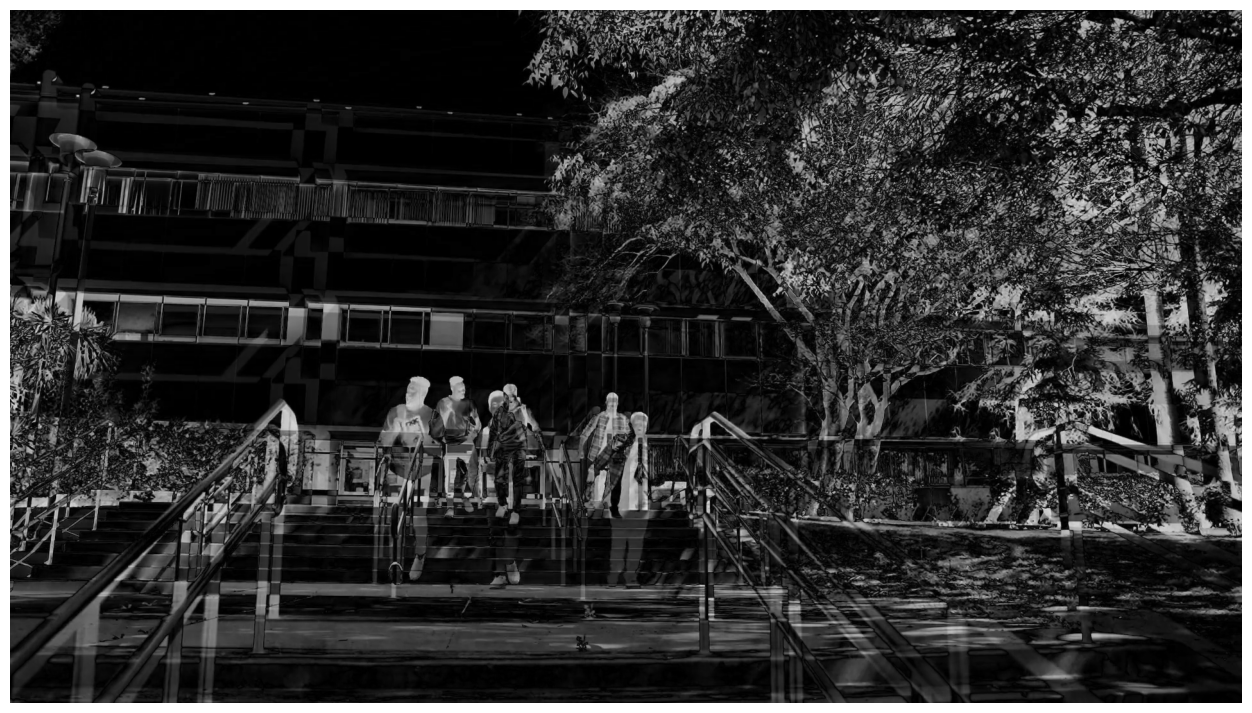

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 9))

plt.imshow(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [6]:
_, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)

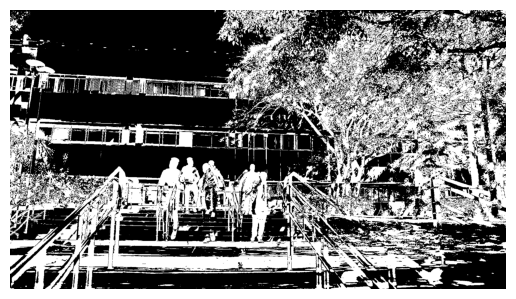

In [7]:
plt.imshow(cv2.cvtColor(thresh, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [8]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

clean = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel
)

In [9]:
clean = cv2.morphologyEx(
    clean,
    cv2.MORPH_CLOSE,
    kernel
)

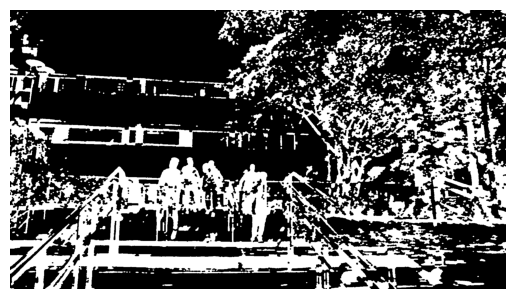

In [10]:
plt.imshow(cv2.cvtColor(clean, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [11]:
contours, _ = cv2.findContours(
    clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [12]:
print("Detected regions:", len(contours))

Detected regions: 749


In [13]:
min_area = 500

motion_contours = [
    contour
    for contour in contours
    if cv2.contourArea(contour) > min_area
]

print("Moving regions:", len(motion_contours))

Moving regions: 62


In [14]:
result = frame2.copy()

for contour in motion_contours:
    x, y, w, h = cv2.boundingRect(contour)

    cv2.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

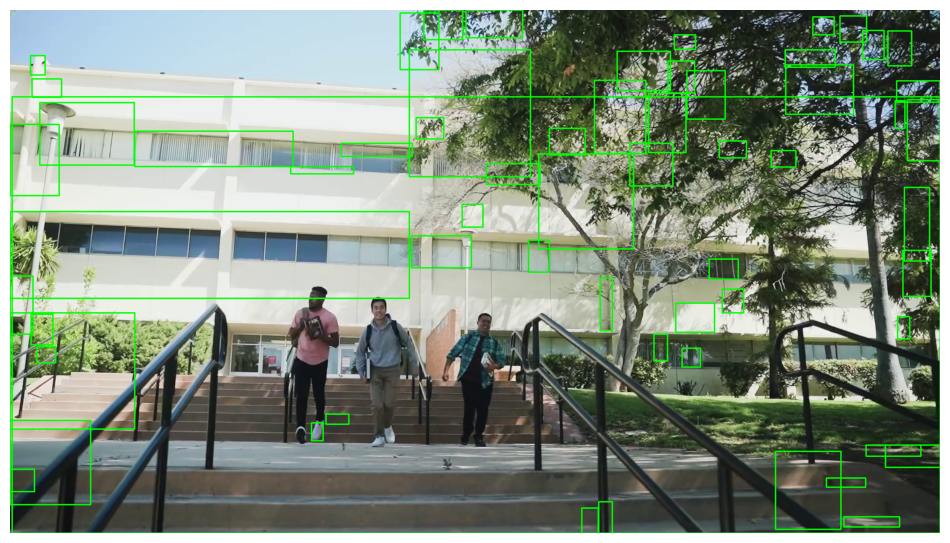

In [15]:
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

```
Frame 1
   ↓
Frame 2
   ↓
absdiff()
   ↓
threshold
   ↓
morphology
   ↓
findContours()
   ↓
filter by area
   ↓
boundingRect()
   ↓
📦 Moving regions

In [19]:
back_sub = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=50,
    detectShadows=True
)

In [24]:
cap = cv2.VideoCapture("assets/people-walking.mp4")

while True:
    ret, frame = cap.read()

    if not ret:
        break

    fg_mask = back_sub.apply(frame)

    _, motion_mask = cv2.threshold(
        fg_mask,
        200,
        255,
        cv2.THRESH_BINARY
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    motion_mask = cv2.morphologyEx(
        motion_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    motion_mask = cv2.morphologyEx(
        motion_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    contours, _ = cv2.findContours(
        motion_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < 500:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

    

    # cv2.imshow("Frame", frame)
    # cv2.imshow("Foreground Mask", fg_mask)
    cv2.imshow("Motion Detection", frame)
    cv2.imshow("Mask", motion_mask)

    if cv2.waitKey(30) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

```
Video
  ↓
MOG2
  ↓
Foreground Mask
  ↓
Remove Shadows
  ↓
Morphology
  ↓
Contours
  ↓
Area Filtering
  ↓
Bounding Boxes
  ↓
Moving Objects 📦

In [25]:
import cv2

cap = cv2.VideoCapture("assets/people-walking.mp4")

back_sub = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=50,
    detectShadows=True
)

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # 1. Background subtraction
    fg_mask = back_sub.apply(frame)

    # 2. Remove shadows
    _, motion_mask = cv2.threshold(
        fg_mask,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # 3. Remove noise
    motion_mask = cv2.morphologyEx(
        motion_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    motion_mask = cv2.morphologyEx(
        motion_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # 4. Find moving regions
    contours, _ = cv2.findContours(
        motion_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # 5. Draw bounding boxes
    moving_objects = 0

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < 500:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        moving_objects += 1

    # 6. Display count
    cv2.putText(
        frame,
        f"Moving objects: {moving_objects}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.imshow("Motion Detection", frame)
    cv2.imshow("Motion Mask", motion_mask)

    if cv2.waitKey(30) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

In [26]:
import cv2

# =========================
# 1. Open video
# =========================

cap = cv2.VideoCapture("assets/people-walking.mp4")

# Background subtractor
back_sub = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=50,
    detectShadows=True
)

# Morphology kernel
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

# Minimum object area
MIN_AREA = 500


# =========================
# 2. Process video
# =========================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # -------------------------
    # Background subtraction
    # -------------------------

    fg_mask = back_sub.apply(frame)

    # -------------------------
    # Remove shadows
    # -------------------------

    _, motion_mask = cv2.threshold(
        fg_mask,
        200,
        255,
        cv2.THRESH_BINARY
    )

    # -------------------------
    # Remove noise
    # -------------------------

    motion_mask = cv2.morphologyEx(
        motion_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    motion_mask = cv2.morphologyEx(
        motion_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # -------------------------
    # Find contours
    # -------------------------

    contours, _ = cv2.findContours(
        motion_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    moving_objects = 0

    # -------------------------
    # Detect moving regions
    # -------------------------

    for contour in contours:

        area = cv2.contourArea(contour)

        if area < MIN_AREA:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        # Draw bounding box
        cv2.rectangle(
            frame,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )

        moving_objects += 1

    # -------------------------
    # Display information
    # -------------------------

    cv2.putText(
        frame,
        f"Moving objects: {moving_objects}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.imshow("Motion Detection", frame)
    cv2.imshow("Motion Mask", motion_mask)

    # Press Q to exit
    if cv2.waitKey(30) & 0xFF == ord("q"):
        break


# =========================
# 3. Release
# =========================

cap.release()
cv2.destroyAllWindows()